In [1]:
import rioxarray as rix
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import plotly.graph_objects as go
from skimage import data, filters, measure, morphology



In [2]:
filepath = r"C:\Users\cquering\Documents\Repository\408\hw4\m_3508228_nw_17_060_20220923.tif"
asheville_data = rix.open_rasterio(filepath)
asheville_data

<xarray.DataArray (band: 4, y: 12380, x: 10300)> Size: 510MB
[510056000 values with dtype=uint8]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 99kB 3.944e+06 3.944e+06 ... 3.936e+06 3.936e+06
  * x            (x) float64 82kB 3.525e+05 3.525e+05 ... 3.587e+05 3.587e+05
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

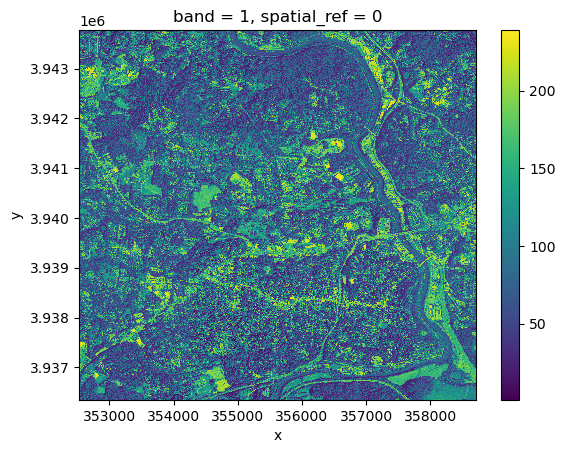

In [3]:
asheville_data[0].plot()

In [3]:
red = asheville_data.sel(band=1)
nearIR = asheville_data.sel(band=4)
normed_red = (red/red.max())*256
normed_nearIR = (nearIR/nearIR.max())*256
ndvi = (normed_nearIR-normed_red)/(normed_nearIR+normed_red)


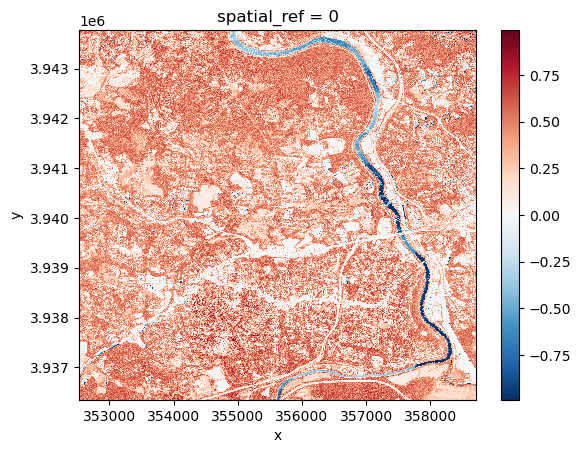

In [5]:
ndvi.plot()

In [4]:
#structures = ndvi < 0.1 and ndvi > -0.1
upperThreshold = ndvi.where(ndvi < 0.1)
structures = upperThreshold.where(ndvi > -0.1)

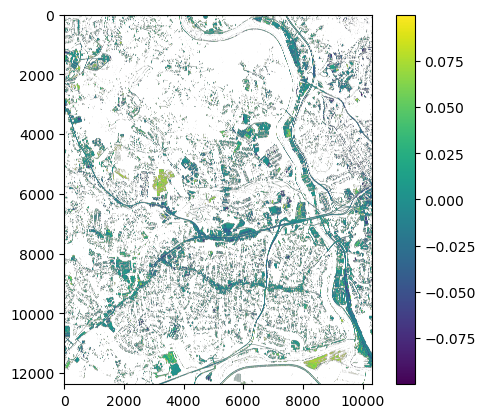

In [5]:
data = structures
img = plt.imshow(data, cmap='viridis')
plt.colorbar(img)
plt.show()



In [5]:
structures_np = structures.values

print(type(structures))

<class 'xarray.core.dataarray.DataArray'>


In [6]:
structures_np

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(12380, 10300))

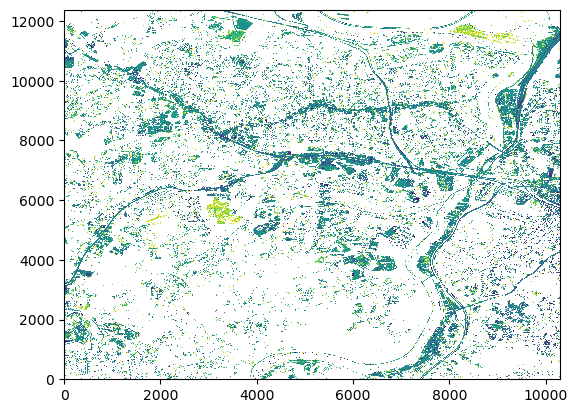

In [7]:
plt.pcolormesh(structures_np)

In [8]:
img = structures_np
# Binary image, post-process the binary mask and compute labels
threshold = filters.threshold_otsu(img)
mask = img > threshold
mask = morphology.remove_small_objects(mask, max_size=49)
mask = morphology.remove_small_holes(mask, max_size=49)
labels = measure.label(mask)

fig = px.imshow(img, binary_string=True)
fig.update_traces(hoverinfo='skip')  # hover is only for label info

props = measure.regionprops(labels, img)
properties = ['area', 'eccentricity', 'perimeter', 'intensity_mean']

# For each label, add a filled scatter trace for its contour,
# and display the properties of the label in the hover of this trace.
for index in range(1, labels.max()):
    label_i = props[index].label
    contour = measure.find_contours(labels == label_i, 0.5)[0]
    y, x = contour.T
    hoverinfo = ''
    for prop_name in properties:
        hoverinfo += f'<b>{prop_name}: {getattr(props[index], prop_name):.2f}</b><br>'
    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            name=label_i,
            mode='lines',
            fill='toself',
            showlegend=False,
            hovertemplate=hoverinfo,
            hoveron='points+fills',
        )
    )

plotly.io.show(fig)

ValueError: autodetected range of [nan, nan] is not finite